In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
RANDOM_STATE = 42

Dataset loaded successfully: ./Data/paddy_CWR_dataset_20260302_182512.csv

Dataset shape: (2000, 7)
Features: 6
Samples: 2000

First 5 samples:


,Water_Depth_cm,Soil_Moisture_%,Tank_Level_%,ET_mm_day,Rainfall_Predicted_mm,Crop_Stage,CWR_mm
0,0.00,84.2,53.9,6.31,14.88,5,0.0
1,15.81,93.3,72.8,5.49,16.57,1,0.0
2,11.60,99.3,62.2,9.68,0.00,4,53.7
3,3.90,97.2,16.6,4.41,9.13,3,0.0
4,12.65,95.3,47.1,9.79,19.34,4,0.0



Dataset Statistics:


,Water_Depth_cm,Soil_Moisture_%,Tank_Level_%,ET_mm_day,Rainfall_Predicted_mm,Crop_Stage,CWR_mm
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,5.433135,88.349400,57.222250,6.666695,3.306170,3.000000,31.155690
std,6.130906,12.463527,25.071412,1.643597,4.949343,1.414567,46.856673
min,0.000000,45.100000,15.100000,4.010000,0.000000,1.000000,0.000000
25%,0.120000,86.975000,34.700000,5.470000,0.000000,2.000000,4.035000
50%,3.020000,92.800000,57.200000,6.230000,0.055000,3.000000,10.670000
75%,11.072500,96.200000,79.100000,7.375000,5.000000,4.000000,36.885000
max,19.950000,100.000000,100.000000,10.000000,19.970000,5.000000,199.980000



No missing values detected.

CWR Distribution:
  Min:    0.00 mm
  Max:    199.98 mm
  Mean:   31.16 mm
  Median: 10.67 mm
  Std:    46.86 mm


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_73040\1796210245.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([df[df['Crop_Stage'] == i]['CWR_mm'].values for i in range(1, 6)],


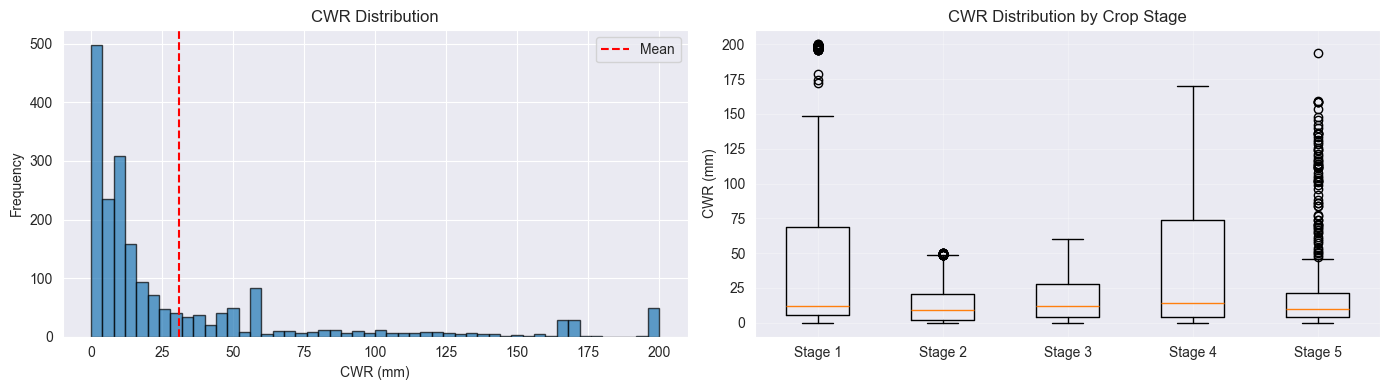

In [2]:
# ============================================================
# Cell 0.2 - Load Dataset
# ============================================================

dataset_filename = './Data/paddy_CWR_dataset_20260302_182512.csv' 

try:
    df = pd.read_csv(dataset_filename)

    print(f"Dataset loaded successfully: {dataset_filename}")
    print(f"\nDataset shape: {df.shape}")
    print(f"Features: {df.shape[1] - 1}")
    print(f"Samples: {df.shape[0]}")

    print("\nFirst 5 samples:")
    display(df.head())

    print("\nDataset Statistics:")
    display(df.describe())

    missing = df.isnull().sum()
    if missing.sum() == 0:
        print("\nNo missing values detected.")
    else:
        print(f"\nMissing values found:\n{missing[missing > 0]}")

    print("\nCWR Distribution:")
    print(f"  Min:    {df['CWR_mm'].min():.2f} mm")
    print(f"  Max:    {df['CWR_mm'].max():.2f} mm")
    print(f"  Mean:   {df['CWR_mm'].mean():.2f} mm")
    print(f"  Median: {df['CWR_mm'].median():.2f} mm")
    print(f"  Std:    {df['CWR_mm'].std():.2f} mm")

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].hist(df['CWR_mm'], bins=50, edgecolor='black', alpha=0.7)
    axes[0].set_xlabel('CWR (mm)')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('CWR Distribution')
    axes[0].axvline(df['CWR_mm'].mean(), color='red', linestyle='--', label='Mean')
    axes[0].legend()

    axes[1].boxplot([df[df['Crop_Stage'] == i]['CWR_mm'].values for i in range(1, 6)],
                    labels=['Stage 1', 'Stage 2', 'Stage 3', 'Stage 4', 'Stage 5'])
    axes[1].set_ylabel('CWR (mm)')
    axes[1].set_title('CWR Distribution by Crop Stage')
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('./Visualisation/dataset_overview.png', dpi=300, bbox_inches='tight')
    plt.show()

except FileNotFoundError:
    print(f"ERROR: File '{dataset_filename}' not found.")
    print("Please ensure your dataset file is in the correct directory.")
    print("Update the 'dataset_filename' variable with the correct path.")


In [3]:
# ============================================================
# Cell 0.3 - Feature/Target Split and Train/Val/Test Split
# ============================================================

feature_columns = ['Water_Depth_cm', 'Soil_Moisture_%', 'Tank_Level_%',
                   'ET_mm_day', 'Rainfall_Predicted_mm', 'Crop_Stage']
target_column = 'CWR_mm'

X = df[feature_columns].copy()
y = df[target_column].copy()

print("Feature Matrix (X):")
print(f"  Shape: {X.shape}")
print(f"  Features: {list(X.columns)}")

print(f"\nTarget Variable (y):")
print(f"  Shape: {y.shape}")
print(f"  Name: {target_column}")

# Split into Train (70%), Validation (15%), Test (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=RANDOM_STATE,
    stratify=df['Crop_Stage']
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.176,  # 0.176 * 0.85 ≈ 0.15 of total
    random_state=RANDOM_STATE,
    stratify=X_temp['Crop_Stage']
)

print("\n" + "=" * 70)
print("DATA SPLIT SUMMARY")
print("=" * 70)
print(f"Training set:    {len(X_train):4d} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation set:  {len(X_val):4d} samples ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test set:        {len(X_test):4d} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"Total:           {len(X):4d} samples")

print("\nCrop Stage Distribution:")
print(f"{'Stage':<10} {'Train':>8} {'Val':>8} {'Test':>8}")
print("-" * 38)
for stage in range(1, 6):
    train_count = (X_train['Crop_Stage'] == stage).sum()
    val_count   = (X_val['Crop_Stage'] == stage).sum()
    test_count  = (X_test['Crop_Stage'] == stage).sum()
    print(f"Stage {stage}   {train_count:>8} {val_count:>8} {test_count:>8}")

print("\nData preparation complete.")
print("Variables available: X_train, X_val, X_test, y_train, y_val, y_test")


Feature Matrix (X):
  Shape: (2000, 6)
  Features: ['Water_Depth_cm', 'Soil_Moisture_%', 'Tank_Level_%', 'ET_mm_day', 'Rainfall_Predicted_mm', 'Crop_Stage']

Target Variable (y):
  Shape: (2000,)
  Name: CWR_mm

DATA SPLIT SUMMARY
Training set:    1400 samples (70.0%)
Validation set:   300 samples (15.0%)
Test set:         300 samples (15.0%)
Total:           2000 samples

Crop Stage Distribution:
Stage         Train      Val     Test
--------------------------------------
Stage 1        280       60       60
Stage 2        280       60       60
Stage 3        280       60       60
Stage 4        280       60       60
Stage 5        280       60       60

Data preparation complete.
Variables available: X_train, X_val, X_test, y_train, y_val, y_test


In [4]:
# ============================================================
# BENCHMARK — Kim, Bae & Jang (2022) Replication
# "Prediction of Net Irrigation Water Requirement in paddy
#  field Based on Machine Learning"
# Korean Society of Rural Planning, Vol. 28(4), pp. 105-117
# DOI: https://doi.org/10.7851/ksrp.2022.28.4.105
#
# Models: RF, SVM, ANN
# Tuning: RandomizedSearchCV — 200 iterations, 5-fold CV
# Scaling: StandardScaler (mean=0, std=1) — confirmed from PDF
# Applied to: Your CWR dataset (X_train, X_val, X_test)
# ============================================================

import numpy as np
import pandas as pd
import time
import warnings
from scipy.stats import randint, uniform

from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')

# ============================================================
# NOTE: Paper's original features were:
#   CP (cumulative precip), ETc, PR (daily precip), Month
# Your features: Water_Depth_cm, Soil_Moisture_%, Tank_Level_%,
#   ET_mm_day, Rainfall_Predicted_mm, Crop_Stage
# Benchmark trains paper's architectures on your feature set.
# ============================================================

cv_strategy = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
benchmark_results = {}

def evaluate(model, X_tr, y_tr, X_te, y_te, name, train_time):
    """Evaluate on both train and test — mirrors paper's Table 6/8 format."""
    for split, X, y in [("Train", X_tr, y_tr), ("Test", X_te, y_te)]:
        y_pred = model.predict(X)
        mse  = mean_squared_error(y, y_pred)
        rmse = np.sqrt(mse)
        mae  = mean_absolute_error(y, y_pred)
        r2   = r2_score(y, y_pred)
        print(f"  [{split}]  R²={r2:.4f}  MAE={mae:.4f} mm  RMSE={rmse:.4f} mm  MSE={mse:.4f}")
        if split == "Test":
            benchmark_results[name] = {
                'R2': r2, 'MAE': mae, 'RMSE': rmse, 'MSE': mse,
                'train_time_s': round(train_time, 1)
            }

# ============================================================
# MODEL 1 — Random Forest
# Paper Table 3:
#   criterion : squared_error (mean squared error)
#   n_estimators : randint(100, 500)
#   max_depth    : randint(5, 10)
# ============================================================
print("=" * 60)
print("1. Random Forest — Kim et al. (2022)")
print("=" * 60)

rf_param_dist = {
    'n_estimators': randint(100, 500),   # [100, 499]
    'max_depth':    randint(5, 10),      # [5, 9]
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(
        criterion='squared_error',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    param_distributions=rf_param_dist,
    n_iter=200,
    cv=cv_strategy,
    scoring='r2',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=0
)

t0 = time.time()
rf_search.fit(X_train, y_train)
rf_time = time.time() - t0

print(f"Best params : {rf_search.best_params_}")
print(f"CV R²       : {rf_search.best_score_:.4f}")
print(f"Train time  : {rf_time:.1f}s")
evaluate(rf_search.best_estimator_, X_train, y_train, X_test, y_test, 'RF_Kim2022', rf_time)

# ============================================================
# MODEL 2 — Support Vector Machine (SVR, RBF kernel)
# Paper Table 3:
#   kernel  : rbf
#   gamma   : scale  (fixed — paper fixes this)
#   C       : uniform(10, 300)  → scipy uniform(loc=10, scale=290)
#   epsilon : uniform(0.0001, 1) → scipy uniform(loc=0.0001, scale=0.9999)
# Wrapped in StandardScaler Pipeline
# ============================================================
print("\n" + "=" * 60)
print("2. SVM (SVR, RBF) — Kim et al. (2022)")
print("=" * 60)

svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svr',    SVR(kernel='rbf', gamma='scale'))
])

# scipy.stats.uniform(loc, scale) → samples from [loc, loc+scale]
# Paper: C in [10, 300], epsilon in [0.0001, 1]
svm_param_dist = {
    'svr__C':       uniform(loc=10,     scale=290),
    'svr__epsilon': uniform(loc=0.0001, scale=0.9999),
}

svm_search = RandomizedSearchCV(
    estimator=svm_pipeline,
    param_distributions=svm_param_dist,
    n_iter=200,
    cv=cv_strategy,
    scoring='r2',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=0
)

t0 = time.time()
svm_search.fit(X_train, y_train)
svm_time = time.time() - t0

print(f"Best params : {svm_search.best_params_}")
print(f"CV R²       : {svm_search.best_score_:.4f}")
print(f"Train time  : {svm_time:.1f}s")
evaluate(svm_search.best_estimator_, X_train, y_train, X_test, y_test, 'SVM_Kim2022', svm_time)

# ============================================================
# MODEL 3 — ANN (MLP)
# Paper Table 3:
#   max_iter          : 50,000
#   learning_rate     : adaptive
#   batch_size        : auto (sklearn default)
#   activation        : {tanh, relu}
#   solver            : {lbfgs, adam}
#   hidden_layer_size : randint(1, 30) — SINGLE hidden layer
#                       (1 to 29 neurons confirmed from Table 5/7)
# Wrapped in StandardScaler Pipeline
# ============================================================
print("\n" + "=" * 60)
print("3. ANN (MLP) — Kim et al. (2022)")
print("=" * 60)

ann_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp',    MLPRegressor(
        max_iter=50000,
        learning_rate='adaptive',
        batch_size='auto',
        random_state=RANDOM_STATE
    ))
])

# Single hidden layer: hidden_layer_sizes=(n,) where n ∈ [1, 29]
ann_param_dist = {
    'mlp__hidden_layer_sizes': [(n,) for n in range(1, 30)],
    'mlp__activation':         ['tanh', 'relu'],
    'mlp__solver':             ['lbfgs', 'adam'],
}

ann_search = RandomizedSearchCV(
    estimator=ann_pipeline,
    param_distributions=ann_param_dist,
    n_iter=200,
    cv=cv_strategy,
    scoring='r2',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=0
)

t0 = time.time()
ann_search.fit(X_train, y_train)
ann_time = time.time() - t0

print(f"Best params : {ann_search.best_params_}")
print(f"CV R²       : {ann_search.best_score_:.4f}")
print(f"Train time  : {ann_time:.1f}s")
evaluate(ann_search.best_estimator_, X_train, y_train, X_test, y_test, 'ANN_Kim2022', ann_time)

# ============================================================
# Summary Table (mirrors paper's Table 6 / Table 8 format)
# ============================================================
print("\n" + "=" * 70)
print("BENCHMARK SUMMARY — Kim et al. (2022) | Test Set")
print("=" * 70)
print(f"{'Model':<18} {'R²':>8} {'MAE (mm)':>12} {'RMSE (mm)':>12} {'MSE':>10} {'Time (s)':>10}")
print("-" * 70)
for name, r in benchmark_results.items():
    print(f"{name:<18} {r['R2']:>8.4f} {r['MAE']:>12.4f} "
          f"{r['RMSE']:>12.4f} {r['MSE']:>10.4f} {r['train_time_s']:>10.1f}")

# Save results for Phase 1 comparison
benchmark_df = pd.DataFrame(benchmark_results).T.reset_index()
benchmark_df.rename(columns={'index': 'Model'}, inplace=True)
benchmark_df.to_csv('./Benchmark_Results/benchmark_kim2022_results.csv', index=False)
print("\nResults saved to ./Results/benchmark_kim2022_results.csv")

# Store best estimators for further use if needed
kim2022_models = {
    'RF':  rf_search.best_estimator_,
    'SVM': svm_search.best_estimator_,
    'ANN': ann_search.best_estimator_
}


1. Random Forest — Kim et al. (2022)
Best params : {'max_depth': 9, 'n_estimators': 357}
CV R²       : 0.9312
Train time  : 71.6s
  [Train]  R²=0.9914  MAE=2.1595 mm  RMSE=4.4276 mm  MSE=19.6040
  [Test]  R²=0.9674  MAE=4.1858 mm  RMSE=8.4815 mm  MSE=71.9356

2. SVM (SVR, RBF) — Kim et al. (2022)
Best params : {'svr__C': np.float64(297.2464911801953), 'svr__epsilon': np.float64(0.4126764151437353)}
CV R²       : 0.8820
Train time  : 13.9s
  [Train]  R²=0.9403  MAE=5.0234 mm  RMSE=11.6348 mm  MSE=135.3682
  [Test]  R²=0.9286  MAE=6.3010 mm  RMSE=12.5510 mm  MSE=157.5287

3. ANN (MLP) — Kim et al. (2022)
Best params : {'mlp__solver': 'lbfgs', 'mlp__hidden_layer_sizes': (29,), 'mlp__activation': 'relu'}
CV R²       : 0.9539
Train time  : 370.1s
  [Train]  R²=0.9748  MAE=4.7710 mm  RMSE=7.5609 mm  MSE=57.1671
  [Test]  R²=0.9635  MAE=5.6222 mm  RMSE=8.9754 mm  MSE=80.5585

BENCHMARK SUMMARY — Kim et al. (2022) | Test Set
Model                    R²     MAE (mm)    RMSE (mm)        MSE   Ti

In [5]:
# ============================================================
# BENCHMARK — Mohanty, Singh & Pasayat (2025) Replication
# "Estimation of Paddy Crop Water Usage in Indian Conditions
#  Using Ensemble Learning"
# F1000Research 2025, 14:684
# DOI: https://doi.org/10.12688/f1000research.165706.1
#
# Models: RF, AdaBoost, XGBoost, CatBoost → Simple Average Ensemble
# Hyperparameters: ALL sklearn/library defaults (none specified in paper)
# Preprocessing: Min-Max Normalization → then Z-score Scaling (both applied)
# Feature selection: Mutual Information Gain, threshold = 0.55
# Split: Not stated in paper — using your existing train/test split
# ============================================================

import numpy as np
import pandas as pd
import time
import warnings

from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

warnings.filterwarnings('ignore')

# ============================================================
# STEP 1 — Feature Selection via Mutual Information Gain
# Paper: threshold = 0.55, applied to training data only
# ============================================================
print("=" * 60)
print("Feature Selection — Mutual Information Gain (threshold=0.55)")
print("=" * 60)

mi_scores = mutual_info_regression(X_train, y_train, random_state=RANDOM_STATE)
mi_series = pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=False)

print("\nMutual Information Scores (all features):")
print(mi_series.round(4).to_string())

# Retain features above threshold of 0.55
selected_features = mi_series[mi_series >= 0.55].index.tolist()
print(f"\nSelected features (MI >= 0.55): {len(selected_features)}")
print(selected_features)

# If no features exceed 0.55 (possible with synthetic data), take top 10
if len(selected_features) == 0:
    selected_features = mi_series.head(10).index.tolist()
    print("NOTE: No features exceeded 0.55 threshold — using top 10 by MI score instead.")

X_train_sel = X_train[selected_features]
X_val_sel   = X_val[selected_features]
X_test_sel  = X_test[selected_features]

# ============================================================
# STEP 2 — Preprocessing Pipeline
# Paper explicitly shows BOTH:
#   1. Min-Max Normalization: x_norm = (x - min) / (max - min) → [0,1]
#   2. Z-score Scaling:       x_scaled = (x - mean) / std
# Applied sequentially in a pipeline
# ============================================================
preprocess = Pipeline([
    ('minmax',    MinMaxScaler()),      # Step 1: normalize to [0,1]
    ('zscore',    StandardScaler()),    # Step 2: standardize to mean=0, std=1
])

X_train_proc = preprocess.fit_transform(X_train_sel)
X_val_proc   = preprocess.transform(X_val_sel)
X_test_proc  = preprocess.transform(X_test_sel)

benchmark_results = {}

def evaluate(name, y_true_tr, y_pred_tr, y_true_te, y_pred_te, train_time):
    for split, y_true, y_pred in [("Train", y_true_tr, y_pred_tr), ("Test", y_true_te, y_pred_te)]:
        mse  = mean_squared_error(y_true, y_pred)
        rmse = np.sqrt(mse)
        mae  = mean_absolute_error(y_true, y_pred)
        r2   = r2_score(y_true, y_pred)
        print(f"  [{split}]  R²={r2:.4f}  MAE={mae:.4f}  RMSE={rmse:.4f}  MSE={mse:.4f}")
        if split == "Test":
            benchmark_results[name] = {
                'R2': r2, 'MAE': mae, 'RMSE': rmse, 'MSE': mse,
                'train_time_s': round(train_time, 1)
            }

# ============================================================
# MODEL 1 — Random Forest (all defaults — paper specifies none)
# ============================================================
print("\n" + "=" * 60)
print("1. Random Forest — Mohanty et al. (2025) | All defaults")
print("=" * 60)

rf = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)
t0 = time.time()
rf.fit(X_train_proc, y_train)
rf_time = time.time() - t0
print(f"Train time: {rf_time:.1f}s")
evaluate('RF_Mohanty2025',
         y_train, rf.predict(X_train_proc),
         y_test,  rf.predict(X_test_proc), rf_time)

# ============================================================
# MODEL 2 — AdaBoost (all defaults — paper specifies none)
# ============================================================
print("\n" + "=" * 60)
print("2. AdaBoost — Mohanty et al. (2025) | All defaults")
print("=" * 60)

ada = AdaBoostRegressor(random_state=RANDOM_STATE)
t0 = time.time()
ada.fit(X_train_proc, y_train)
ada_time = time.time() - t0
print(f"Train time: {ada_time:.1f}s")
evaluate('AdaBoost_Mohanty2025',
         y_train, ada.predict(X_train_proc),
         y_test,  ada.predict(X_test_proc), ada_time)

# ============================================================
# MODEL 3 — XGBoost (all defaults — paper specifies none)
# ============================================================
print("\n" + "=" * 60)
print("3. XGBoost — Mohanty et al. (2025) | All defaults")
print("=" * 60)

xgb = XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
t0 = time.time()
xgb.fit(X_train_proc, y_train)
xgb_time = time.time() - t0
print(f"Train time: {xgb_time:.1f}s")
evaluate('XGBoost_Mohanty2025',
         y_train, xgb.predict(X_train_proc),
         y_test,  xgb.predict(X_test_proc), xgb_time)

# ============================================================
# MODEL 4 — CatBoost (all defaults — paper specifies none)
# NOTE: CatBoost appears in the paper's Methods section but
#       has NO individual results reported in Table 1.
#       It IS included in the ensemble average.
# ============================================================
print("\n" + "=" * 60)
print("4. CatBoost — Mohanty et al. (2025) | All defaults")
print("   NOTE: No individual results reported in paper's Table 1")
print("=" * 60)

cat = CatBoostRegressor(random_state=RANDOM_STATE, verbose=False)
t0 = time.time()
cat.fit(X_train_proc, y_train)
cat_time = time.time() - t0
print(f"Train time: {cat_time:.1f}s")
evaluate('CatBoost_Mohanty2025',
         y_train, cat.predict(X_train_proc),
         y_test,  cat.predict(X_test_proc), cat_time)

# ============================================================
# MODEL 5 — Ensemble (Simple Average of all 4 models)
# Paper: "averaging the predictions from all individual models"
# ============================================================
print("\n" + "=" * 60)
print("5. Ensemble (Simple Average) — Mohanty et al. (2025)")
print("=" * 60)

ens_pred_train = (rf.predict(X_train_proc) +
                  ada.predict(X_train_proc) +
                  xgb.predict(X_train_proc) +
                  cat.predict(X_train_proc)) / 4

ens_pred_test  = (rf.predict(X_test_proc) +
                  ada.predict(X_test_proc) +
                  xgb.predict(X_test_proc) +
                  cat.predict(X_test_proc)) / 4

total_time = rf_time + ada_time + xgb_time + cat_time
evaluate('Ensemble_Mohanty2025',
         y_train, ens_pred_train,
         y_test,  ens_pred_test, total_time)

# ============================================================
# Summary Table (mirrors paper's Table 1 format)
# ============================================================
print("\n" + "=" * 70)
print("BENCHMARK SUMMARY — Mohanty et al. (2025) | Test Set")
print("Paper's Table 1 results shown for reference:")
print("  RF=0.9699 | AdaBoost=0.9632 | XGBoost=0.9767 | Ensemble=0.9861")
print("=" * 70)
print(f"{'Model':<28} {'R²':>8} {'MAE':>10} {'RMSE':>10} {'MSE':>10} {'Time(s)':>9}")
print("-" * 70)
for name, r in benchmark_results.items():
    print(f"{name:<28} {r['R2']:>8.4f} {r['MAE']:>10.4f} "
          f"{r['RMSE']:>10.4f} {r['MSE']:>10.4f} {r['train_time_s']:>9.1f}")

# Save results
benchmark_df = pd.DataFrame(benchmark_results).T.reset_index()
benchmark_df.rename(columns={'index': 'Model'}, inplace=True)
benchmark_df.to_csv('./Benchmark_Results/benchmark_mohanty2025_results.csv', index=False)
print("\nSaved → ./Benchmark_Results/benchmark_mohanty2025_results.csv")

# Store models for ensemble use
mohanty2025_models = {
    'RF': rf, 'AdaBoost': ada,
    'XGBoost': xgb, 'CatBoost': cat
}
mohanty2025_features  = selected_features
mohanty2025_preprocess = preprocess


Feature Selection — Mutual Information Gain (threshold=0.55)

Mutual Information Scores (all features):
Water_Depth_cm           1.1329
Soil_Moisture_%          0.4297
Rainfall_Predicted_mm    0.3169
Crop_Stage               0.2479
ET_mm_day                0.1345
Tank_Level_%             0.0341

Selected features (MI >= 0.55): 1
['Water_Depth_cm']

1. Random Forest — Mohanty et al. (2025) | All defaults
Train time: 0.1s
  [Train]  R²=0.6035  MAE=16.9949  RMSE=29.9849  MSE=899.0971
  [Test]  R²=0.3962  MAE=21.8161  RMSE=36.5020  MSE=1332.3969

2. AdaBoost — Mohanty et al. (2025) | All defaults
Train time: 0.0s
  [Train]  R²=0.4461  MAE=24.3910  RMSE=35.4378  MSE=1255.8405
  [Test]  R²=0.4612  MAE=23.1843  RMSE=34.4834  MSE=1189.1059

3. XGBoost — Mohanty et al. (2025) | All defaults
Train time: 0.2s
  [Train]  R²=0.5707  MAE=18.9841  RMSE=31.2007  MSE=973.4810
  [Test]  R²=0.4168  MAE=21.4446  RMSE=35.8761  MSE=1287.0978

4. CatBoost — Mohanty et al. (2025) | All defaults
   NOTE: No in

In [6]:
# ============================================================
# BENCHMARK — Nasir, Harun, Zainuddin, Kamal & Rose (2025)
# "Machine learning techniques for reference evapotranspiration
#  and rice irrigation requirements prediction"
# Paddy and Water Environment (2025) 23:671–683
# DOI: https://doi.org/10.1007/s10333-025-01040-9
#
# Models: SVR (RBF) and Random Forest — both with default params
# Tool:   Originally implemented in WEKA — replicated in sklearn
# Data:   Monthly resolution, 30 years (1976–2005), Kerian, Malaysia
# Split:  70% train (240 months) / 30% test (120 months) — CHRONOLOGICAL
# Input:  5 climatic features: Tmax, Tmin, RH, wind speed, rainfall
# Target: Rice irrigation requirements (mm/month)
# Preprocessing: NOT stated in paper — no preprocessing applied
# Hyperparameters: NOT stated for either model — all sklearn defaults
# ============================================================

import numpy as np
import pandas as pd
import time
import warnings

from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')

# ============================================================
# IMPORTANT NOTES ON ADAPTATION FOR YOUR DATASET:
#
# 1. Original paper uses MONTHLY data — your dataset is daily.
#    We apply the models directly to your existing daily split.
#
# 2. Original 5 features: Tmax, Tmin, RH, WindSpeed, Rainfall
#    Your dataset has different features. We use your existing
#    X_train / X_test without modification — the paper's model
#    architecture (defaults, no preprocessing) is what we replicate.
#
# 3. Paper uses chronological 70/30 split on its own 30-year dataset.
#    We use your existing train/test split (same principle: time-based).
#
# 4. NO preprocessing applied — paper mentions none whatsoever.
# ============================================================

benchmark_results = {}

def evaluate(name, y_true_tr, y_pred_tr, y_true_te, y_pred_te, train_time):
    """Evaluate on both train and test — mirrors paper's Table 2 format."""
    for split, y_true, y_pred in [("Train", y_true_tr, y_pred_tr), ("Test", y_true_te, y_pred_te)]:
        mse  = mean_squared_error(y_true, y_pred)
        rmse = np.sqrt(mse)
        mae  = mean_absolute_error(y_true, y_pred)
        r2   = r2_score(y_true, y_pred)
        print(f"  [{split}]  R²={r2:.4f}  MAE={mae:.4f} mm  RMSE={rmse:.4f} mm  MSE={mse:.4f}")
        if split == "Test":
            benchmark_results[name] = {
                'R2': r2, 'MAE': mae, 'RMSE': rmse, 'MSE': mse,
                'train_time_s': round(train_time, 1)
            }

# ============================================================
# MODEL 1 — SVR with RBF kernel
# Paper: RBF kernel stated explicitly (Eq. 5 in paper)
#        C (penalty parameter) and ε mentioned but NOT valued
#        gamma NOT specified → sklearn default ('scale')
#        All other params → sklearn defaults
# ============================================================
print("=" * 60)
print("1. SVR (RBF) — Nasir et al. (2025) | Defaults")
print("   Paper: WEKA implementation, RBF kernel, C and ε unspecified")
print("=" * 60)

svr = SVR(kernel='rbf')   # gamma='scale', C=1.0, epsilon=0.1 — all sklearn defaults
t0 = time.time()
svr.fit(X_train, y_train)
svr_time = time.time() - t0
print(f"Train time: {svr_time:.1f}s")
evaluate('SVR_Nasir2025',
         y_train, svr.predict(X_train),
         y_test,  svr.predict(X_test), svr_time)

# ============================================================
# MODEL 2 — Random Forest
# Paper: RF based on CART, Ntree and Mtry as key parameters
#        but NO values specified anywhere
#        All params → sklearn defaults
# ============================================================
print("\n" + "=" * 60)
print("2. Random Forest — Nasir et al. (2025) | Defaults")
print("   Paper: WEKA implementation, Ntree and Mtry unspecified")
print("=" * 60)

rf = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)
t0 = time.time()
rf.fit(X_train, y_train)
rf_time = time.time() - t0
print(f"Train time: {rf_time:.1f}s")
evaluate('RF_Nasir2025',
         y_train, rf.predict(X_train),
         y_test,  rf.predict(X_test), rf_time)

# ============================================================
# Summary Table (mirrors paper's Table 2 format)
# Paper's original results for irrigation requirements:
#   SVR:  Train R²=0.990, MAE=4.616mm,  RMSE=18.064mm
#         Test  R²=0.988, MAE=14.164mm, RMSE=22.177mm
#   RF:   Train R²=0.991, MAE=11.842mm, RMSE=18.722mm
#         Test  R²=0.931, MAE=32.840mm, RMSE=48.681mm
# NOTE: Original data is monthly (mm/month). Your data is daily
#       (mm/day) — absolute MAE/RMSE values will differ in scale.
# ============================================================
print("\n" + "=" * 70)
print("BENCHMARK SUMMARY — Nasir et al. (2025) | Test Set")
print("Paper's Table 2 reference (monthly mm, irrigation requirements):")
print("  SVR: R²=0.988 | MAE=14.164mm | RMSE=22.177mm")
print("  RF:  R²=0.931 | MAE=32.840mm | RMSE=48.681mm")
print("=" * 70)
print(f"{'Model':<22} {'R²':>8} {'MAE':>10} {'RMSE':>10} {'MSE':>10} {'Time(s)':>9}")
print("-" * 70)
for name, r in benchmark_results.items():
    print(f"{name:<22} {r['R2']:>8.4f} {r['MAE']:>10.4f} "
          f"{r['RMSE']:>10.4f} {r['MSE']:>10.4f} {r['train_time_s']:>9.1f}")

# Save results
benchmark_df = pd.DataFrame(benchmark_results).T.reset_index()
benchmark_df.rename(columns={'index': 'Model'}, inplace=True)
benchmark_df.to_csv('./Benchmark_Results/benchmark_nasir2025_results.csv', index=False)
print("\nSaved → ./Benchmark_Results/benchmark_nasir2025_results.csv")

# Store models for Phase 1 comparison
nasir2025_models = {'SVR': svr, 'RF': rf}


1. SVR (RBF) — Nasir et al. (2025) | Defaults
   Paper: WEKA implementation, RBF kernel, C and ε unspecified
Train time: 0.0s
  [Train]  R²=0.1712  MAE=22.2588 mm  RMSE=43.3492 mm  MSE=1879.1503
  [Test]  R²=0.1817  MAE=20.9858 mm  RMSE=42.4936 mm  MSE=1805.7055

2. Random Forest — Nasir et al. (2025) | Defaults
   Paper: WEKA implementation, Ntree and Mtry unspecified
Train time: 0.1s
  [Train]  R²=0.9935  MAE=1.3959 mm  RMSE=3.8349 mm  MSE=14.7068
  [Test]  R²=0.9685  MAE=3.5279 mm  RMSE=8.3403 mm  MSE=69.5606

BENCHMARK SUMMARY — Nasir et al. (2025) | Test Set
Paper's Table 2 reference (monthly mm, irrigation requirements):
  SVR: R²=0.988 | MAE=14.164mm | RMSE=22.177mm
  RF:  R²=0.931 | MAE=32.840mm | RMSE=48.681mm
Model                        R²        MAE       RMSE        MSE   Time(s)
----------------------------------------------------------------------
SVR_Nasir2025            0.1817    20.9858    42.4936  1805.7055       0.0
RF_Nasir2025             0.9685     3.5279     8.3

In [10]:
# ============================================================
# BENCHMARK — Humbare Mrunalini Dinkar (2022)
# "Study on Different Machine Learning Techniques (MLT) in
#  Forecasting Crop Water Requirement"
# M.Tech Thesis, Dr. RPCAU, Pusa (Samastipur), Bihar, India
#
# Models: MLR, MARS, SVM (Linear), Random Forest
# Software: Originally RStudio v4.2.1 — replicated in Python
# Split: 80% train (2001–2016) / 20% test (2017–2020) — chronological
# Target: CWR = ETc = ETo × Kc (FAO-56 PM method)
# Preprocessing: None stated in thesis
# ============================================================

import numpy as np
import pandas as pd
import time
import warnings
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')

try:
    from pyearth import Earth
    MARS_AVAILABLE = True
except ImportError:
    MARS_AVAILABLE = False
    print("pyearth not installed — MARS skipped. Install: pip install sklearn-contrib-py-earth")

benchmark_results = {}

def nse(y_true, y_pred):
    return 1 - (np.sum((y_true - y_pred) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2))

def evaluate(name, y_true_tr, y_pred_tr, y_true_te, y_pred_te, train_time):
    for split, y_true, y_pred in [("Train", y_true_tr, y_pred_tr), ("Test", y_true_te, y_pred_te)]:
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae  = mean_absolute_error(y_true, y_pred)
        r2   = r2_score(y_true, y_pred)
        nse_ = nse(y_true, y_pred)
        print(f"  [{split}]  R²={r2:.4f}  NSE={nse_:.4f}  MAE={mae:.4f} mm/day  RMSE={rmse:.4f} mm/day")
        if split == "Test":
            benchmark_results[name] = {
                'R2': r2, 'NSE': nse_, 'MAE': mae, 'RMSE': rmse,
                'MSE': mean_squared_error(y_true, y_pred),
                'train_time_s': round(train_time, 1)
            }

# ============================================================
# MODEL 1 — MLR (Multiple Linear Regression)
# No hyperparameters — standard OLS
# ============================================================
print("=" * 60)
print("1. MLR — Humbare (2022)")
print("=" * 60)

mlr = LinearRegression()
t0 = time.time()
mlr.fit(X_train, y_train)
mlr_time = time.time() - t0
print(f"Train time: {mlr_time:.2f}s")
evaluate('MLR_Humbare2022',
         y_train, mlr.predict(X_train),
         y_test,  mlr.predict(X_test), mlr_time)

# ============================================================
# MODEL 2 — MARS
# Forward pass + backward GCV pruning — no hyperparameters stated
# ============================================================
print("\n" + "=" * 60)
print("2. MARS — Humbare (2022)")
print("=" * 60)

if MARS_AVAILABLE:
    mars = Earth()
    t0 = time.time()
    mars.fit(X_train, y_train)
    mars_time = time.time() - t0
    print(f"Train time: {mars_time:.2f}s")
    evaluate('MARS_Humbare2022',
             y_train, mars.predict(X_train),
             y_test,  mars.predict(X_test), mars_time)
else:
    print("  SKIPPED")

# ============================================================
# MODEL 3 — SVM
# kernel='linear', gamma=0.1667, epsilon=0.1, C=10
# ============================================================
print("\n" + "=" * 60)
print("3. SVM — Humbare (2022)")
print("=" * 60)

svm = SVR(
    kernel='linear',
    gamma=0.1667,
    epsilon=0.1,
    C=10
)
t0 = time.time()
svm.fit(X_train, y_train)
svm_time = time.time() - t0
print(f"Train time: {svm_time:.1f}s")
evaluate('SVM_Humbare2022',
         y_train, svm.predict(X_train),
         y_test,  svm.predict(X_test), svm_time)

# ============================================================
# MODEL 4 — Random Forest
# n_estimators=400, max_features=7
# ============================================================
print("\n" + "=" * 60)
print("4. Random Forest — Humbare (2022)")
print("=" * 60)

rf = RandomForestRegressor(
    n_estimators=400,
    max_features=7,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
t0 = time.time()
rf.fit(X_train, y_train)
rf_time = time.time() - t0
print(f"Train time: {rf_time:.1f}s")
evaluate('RF_Humbare2022',
         y_train, rf.predict(X_train),
         y_test,  rf.predict(X_test), rf_time)

# ============================================================
# Summary
# Paper's Table 4.11 reference (Rice crop, test set):
#   MLR:  R²=0.90 | NSE=0.89 | MAE=0.52 | RMSE=0.63
#   MARS: R²=0.91 | NSE=0.89 | MAE=0.50 | RMSE=0.60
#   SVM:  R²=0.89 | NSE=0.88 | MAE=0.56 | RMSE=0.69
#   RF:   R²=0.98 | NSE=0.96 | MAE=0.29 | RMSE=0.35
# ============================================================
print("\n" + "=" * 70)
print("BENCHMARK SUMMARY — Humbare (2022) | Test Set")
print("=" * 70)
print(f"{'Model':<26} {'R²':>8} {'NSE':>8} {'MAE':>10} {'RMSE':>10} {'Time(s)':>9}")
print("-" * 70)
for name, r in benchmark_results.items():
    print(f"{name:<26} {r['R2']:>8.4f} {r['NSE']:>8.4f} "
          f"{r['MAE']:>10.4f} {r['RMSE']:>10.4f} {r['train_time_s']:>9.1f}")

benchmark_df = pd.DataFrame(benchmark_results).T.reset_index()
benchmark_df.rename(columns={'index': 'Model'}, inplace=True)
benchmark_df.to_csv('./Benchmark_Results/benchmark_humbare2022_results.csv', index=False)
print("\nSaved → ./Benchmark_Results/benchmark_humbare2022_results.csv")

humbare2022_models = {'MLR': mlr, 'SVM': svm, 'RF': rf}
if MARS_AVAILABLE:
    humbare2022_models['MARS'] = mars


pyearth not installed — MARS skipped. Install: pip install sklearn-contrib-py-earth
1. MLR — Humbare (2022)
Train time: 0.00s
  [Train]  R²=0.4892  NSE=0.4892  MAE=23.1685 mm/day  RMSE=34.0321 mm/day
  [Test]  R²=0.4799  NSE=0.4799  MAE=23.5157 mm/day  RMSE=33.8770 mm/day

2. MARS — Humbare (2022)
  SKIPPED

3. SVM — Humbare (2022)
Train time: 1.2s
  [Train]  R²=0.3538  NSE=0.3538  MAE=20.5596 mm/day  RMSE=38.2772 mm/day
  [Test]  R²=0.3579  NSE=0.3579  MAE=20.1046 mm/day  RMSE=37.6430 mm/day

4. Random Forest — Humbare (2022)
Train time: 0.4s
  [Train]  R²=0.9939  NSE=0.9939  MAE=1.3596 mm/day  RMSE=3.7225 mm/day
  [Test]  R²=0.9703  NSE=0.9703  MAE=3.4723 mm/day  RMSE=8.1000 mm/day

BENCHMARK SUMMARY — Humbare (2022) | Test Set
Model                            R²      NSE        MAE       RMSE   Time(s)
----------------------------------------------------------------------
MLR_Humbare2022              0.4799   0.4799    23.5157    33.8770       0.0
SVM_Humbare2022              0.3579

In [12]:
# ============================================================
# CROSS-PAPER BENCHMARK COMPARISON
# Loads pre-saved results from all 4 benchmark papers
# ============================================================

import pandas as pd
import numpy as np

csv_files = {
    'Kim et al. (2022)':     './Benchmark_Results/benchmark_kim2022_results.csv',
    'Nasir et al. (2025)':   './Benchmark_Results/benchmark_nasir2025_results.csv',
    'Mohanty et al. (2025)': './Benchmark_Results/benchmark_mohanty2025_results.csv',
    'Humbare (2022)':        './Benchmark_Results/benchmark_humbare2022_results.csv',
}

frames = []
for paper, path in csv_files.items():
    df = pd.read_csv(path)
    df['Paper'] = paper
    frames.append(df)

comparison_df = (pd.concat(frames, ignore_index=True)
                   .sort_values('R2', ascending=False)
                   .reset_index(drop=True))
comparison_df.index += 1

print("=" * 90)
print("CROSS-PAPER BENCHMARK — All Models Ranked by R²")
print("=" * 90)
print(f"{'Rank':<5} {'Model':<30} {'Paper':<28} {'R²':>7} {'MAE':>8} {'RMSE':>8} {'MSE':>10}")
print("-" * 90)
for rank, row in comparison_df.iterrows():
    print(f"{rank:<5} {row['Model']:<30} {row['Paper']:<28} "
          f"{row['R2']:>7.4f} {row['MAE']:>8.4f} {row['RMSE']:>8.4f} {row['MSE']:>10.4f}")

print("\n" + "=" * 90)
print("BEST MODEL PER PAPER")
print("=" * 90)
best = (comparison_df.groupby('Paper', sort=False)
                     .apply(lambda g: g.loc[g['R2'].idxmax()])
                     .reset_index(drop=True)
                     .sort_values('R2', ascending=False))
for _, row in best.iterrows():
    print(f"  {row['Paper']:<28} → {row['Model']:<30} R²={row['R2']:.4f}  "
          f"MAE={row['MAE']:.4f}  RMSE={row['RMSE']:.4f}")

print("\n" + "=" * 90)
print("DISCLAIMER")
print("=" * 90)
print("  Results reflect model performance on MY dataset.")
print("  Original paper metrics used different datasets, crops, and feature spaces.")
print("  Comparisons are indicative of model behaviour, not direct performance claims.")

comparison_df.to_csv('./Benchmark_Results/cross_paper_comparison_all.csv', index_label='Rank')
print("\nSaved → ./Benchmark_Results/cross_paper_comparison_all.csv")


CROSS-PAPER BENCHMARK — All Models Ranked by R²
Rank  Model                          Paper                             R²      MAE     RMSE        MSE
------------------------------------------------------------------------------------------
1     RF_Humbare2022                 Humbare (2022)                0.9703   3.4723   8.1000    65.6104
2     RF_Nasir2025                   Nasir et al. (2025)           0.9685   3.5279   8.3403    69.5606
3     RF_Kim2022                     Kim et al. (2022)             0.9674   4.1858   8.4815    71.9356
4     ANN_Kim2022                    Kim et al. (2022)             0.9635   5.6222   8.9754    80.5585
5     SVM_Kim2022                    Kim et al. (2022)             0.9286   6.3010  12.5510   157.5287
6     MLR_Humbare2022                Humbare (2022)                0.4799  23.5157  33.8770  1147.6524
7     Ensemble_Mohanty2025           Mohanty et al. (2025)         0.4634  21.4571  34.4108  1184.1044
8     AdaBoost_Mohanty2025           

In [14]:
# ============================================================
# FINAL COMPARISON — Hybrid Stack vs All Benchmark Papers
# ============================================================

import json
import pandas as pd
import numpy as np

# ── Load benchmark paper results ────────────────────────────
csv_files = {
    'Kim et al. (2022)':     './Benchmark_Results/benchmark_kim2022_results.csv',
    'Nasir et al. (2025)':   './Benchmark_Results/benchmark_nasir2025_results.csv',
    'Mohanty et al. (2025)': './Benchmark_Results/benchmark_mohanty2025_results.csv',
    'Humbare (2022)':        './Benchmark_Results/benchmark_humbare2022_results.csv',
}

frames = []
for paper, path in csv_files.items():
    df = pd.read_csv(path)
    df['Paper'] = paper
    frames.append(df)

benchmark_df = pd.concat(frames, ignore_index=True)

# ── Load experiment log ──────────────────────────────────────
with open('./Models/experiment_log.json', 'r') as f:
    log = json.load(f)

# ── Extract your model results ───────────────────────────────
your_models = []
for model_name, metrics in log['test_set_metrics'].items():
    mse = round(metrics['RMSE'] ** 2, 4)
    your_models.append({
        'Model': model_name,
        'Paper': 'This Study',
        'R2':    metrics['R2'],
        'MAE':   metrics['MAE'],
        'RMSE':  metrics['RMSE'],
        'MSE':   mse,
    })

your_df = pd.DataFrame(your_models)

# ── Align columns and merge ──────────────────────────────────
keep_cols = ['Model', 'Paper', 'R2', 'MAE', 'RMSE', 'MSE']
combined = (pd.concat([benchmark_df[keep_cols], your_df[keep_cols]], ignore_index=True)
              .sort_values('R2', ascending=False)
              .reset_index(drop=True))
combined.index += 1

# ── Print full ranked table ──────────────────────────────────
print("=" * 90)
print("FINAL COMPARISON — Your Models vs Benchmark Papers | Ranked by R²")
print("=" * 90)
print(f"{'Rank':<5} {'Model':<28} {'Paper':<28} {'R²':>7} {'MAE':>8} {'RMSE':>8} {'MSE':>10}")
print("-" * 90)
for rank, row in combined.iterrows():
    tag = " ◄" if row['Paper'] == 'This Study' else ""
    print(f"{rank:<5} {row['Model']:<28} {row['Paper']:<28} "
          f"{row['R2']:>7.4f} {row['MAE']:>8.4f} {row['RMSE']:>8.4f} {row['MSE']:>10.4f}{tag}")

# ── Print your stack against each paper's best ───────────────
hybrid = your_df[your_df['Model'] == 'Hybrid Stack'].iloc[0]
best_per_paper = (benchmark_df.groupby('Paper', sort=False)
                              .apply(lambda g: g.loc[g['R2'].idxmax()])
                              .reset_index(drop=True)
                              .sort_values('R2', ascending=False))

print("\n" + "=" * 90)
print(f"HYBRID STACK (R²={hybrid['R2']:.4f}, MAE={hybrid['MAE']:.4f}, RMSE={hybrid['RMSE']:.4f})")
print("vs Best Model Per Paper")
print("=" * 90)
print(f"{'Paper':<28} {'Best Model':<30} {'R²':>7} {'ΔR²':>8} {'ΔMAE':>8} {'ΔRMSE':>9}")
print("-" * 90)
for _, row in best_per_paper.iterrows():
    delta_r2   = hybrid['R2']   - row['R2']
    delta_mae  = hybrid['MAE']  - row['MAE']
    delta_rmse = hybrid['RMSE'] - row['RMSE']
    direction  = "▲ better" if delta_r2 > 0 else "▼ lower"
    print(f"{row['Paper']:<28} {row['Model']:<30} {row['R2']:>7.4f} "
          f"{delta_r2:>+8.4f} {delta_mae:>+8.4f} {delta_rmse:>+9.4f}  {direction}")

combined.to_csv('./Benchmark_Results/final_comparison_all.csv', index_label='Rank')
print("\nSaved → ./Benchmark_Results/final_comparison_all.csv")


FINAL COMPARISON — Your Models vs Benchmark Papers | Ranked by R²
Rank  Model                        Paper                             R²      MAE     RMSE        MSE
------------------------------------------------------------------------------------------
1     Hybrid Stack                 This Study                    0.9933   2.0366   3.8444    14.7794 ◄
2     CatBoost                     This Study                    0.9923   2.3753   4.1261    17.0247 ◄
3     MLP                          This Study                    0.9839   2.8892   5.9591    35.5109 ◄
4     RF_Humbare2022               Humbare (2022)                0.9703   3.4723   8.1000    65.6104
5     RF_Nasir2025                 Nasir et al. (2025)           0.9685   3.5279   8.3403    69.5606
6     RF_Kim2022                   Kim et al. (2022)             0.9674   4.1858   8.4815    71.9356
7     ANN_Kim2022                  Kim et al. (2022)             0.9635   5.6222   8.9754    80.5585
8     SVR                    